## Group No 169

## Group Member Names:
1. Payel Karmakar (2024AA05423)
2. Krithika Madhavan (2024AA05421)
3. Yarragondla Rugmangadha Reddy (2024AA05435)
4. Rahul Agarwal (2024AA05676)

## Journal used for the implemetation
Journal title: An effective multiclass skin cancer classification approach based on deep convolutional neural network

Authors: Essam H. Houssein, Doaa A. Abdelkareem, Gang Hu, Mohamed Abdel Hameed, Ibrahim A. Ibrahim, Mina Younan

Journal Name: An effective multiclass skin cancer classification approach based on deep convolutional neural network

Year: 2024

# 1. Import the required libraries

In [ ]:
##---------Type the code below this line------------------##
# ==============================
# 1) Setup & Imports
# ==============================
import os, random, math, itertools, json, gc
from pathlib import Path

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc, precision_recall_fscore_support

# For reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)



TensorFlow: 2.19.0
GPU available: True


# 2. Data Acquisition

For the problem identified by you, students have to find the data source themselves from any data source.

* Provide the URL of the data used. HAM10000: [link](https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000)

Write Code for converting the above downloaded data into a form suitable for DL

# Skin Cancer MNIST: HAM10000
This notebook implements a **Deep Convolutional Neural Network (DCNN)** for **HAM10000** classification **exactly following the solution approach from the referenced paper**.  
Key choices (from the paper):
- Input size **64×64**
- **8 Conv layers** in 4 pairs with BatchNorm, then MaxPool, then Dense(256→128→64) with Dropout(0.5)
- **Optimizer: Adamax (lr=1e-3)**
- **Loss:** categorical crossentropy
- **Train/Test:** 80/20 split
- **Class imbalance:** handled via **random oversampling** (and/or class weights as a fallback)
- **Metrics:** accuracy, precision, recall, F1, specificity, AUC; Confusion Matrix; **Grad-CAM**



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
##---------Type the code below this line------------------##
# Paths — UPDATE these to your actual locations

from pathlib import Path
import pandas as pd

# Path to dataset in Google Drive
DATASET_DIR = Path('/content/drive/MyDrive/archive')

# Image directories
IMAGES_DIRS = [
    DATASET_DIR / 'HAM10000_images_part_1',
    DATASET_DIR / 'HAM10000_images_part_2'
]

# Metadata CSV (make sure filename includes .csv)
META_PATH = DATASET_DIR / 'HAM10000_metadata.csv'

# Classes
CLASSES = ['akiec','bcc','bkl','df','mel','nv','vasc']
CLASS_TO_IDX = {c:i for i,c in enumerate(CLASSES)}
IDX_TO_CLASS = {i:c for c,i in CLASS_TO_IDX.items()}

# --- Load metadata ---
def load_metadata(meta_path: Path):
    df = pd.read_csv(meta_path)
    # Only keep relevant columns
    df = df[['image_id', 'dx']].copy()
    df = df[df['dx'].isin(CLASSES)].copy()
    df['label_idx'] = df['dx'].map(CLASS_TO_IDX)

    # Add full image path
    def image_path(image_id):
        fname = f"{image_id}.jpg"
        for d in IMAGES_DIRS:
            p = d / fname
            if p.exists():
                return str(p)
        return None

    df['image_path'] = df['image_id'].apply(image_path)
    df = df.dropna(subset=['image_path'])
    return df

# Load dataset
df_all = load_metadata(META_PATH)
print("Total images loaded:", len(df_all))
print("Class distribution:")
print(df_all['dx'].value_counts())

# 3. Data Preparation

Perform the data prepracessing that is required for the data that you have downloaded.

This stage depends on the dataset that is used.
- Resize to **64×64**
- Normalize to **[0,1]**
- Address **class imbalance** using **random oversampling** of minority classes on the *training split*
- Data augmentation (optional, modest) to reduce overfitting


In [ ]:
##---------Type the code below this line------------------##

## Split the data into training set and testing set
##---------Type the code below this line------------------##

## Identify the target variables.
##---------Type the code below this line------------------##
# Classes (7 lesion types)
CLASSES = ['akiec','bcc','bkl','df','mel','nv','vasc']
CLASS_TO_IDX = {c:i for i,c in enumerate(CLASSES)}
IDX_TO_CLASS = {i:c for c,i in CLASS_TO_IDX.items()}

IMG_SIZE = (64, 64)
BATCH_SIZE = 128

def load_metadata(meta_path: Path):
    df = pd.read_csv(meta_path)
    # The metadata has columns: image_id, dx (label), and more. We keep needed columns.
    df = df[['image_id', 'dx']].copy()
    # Map labels to indices
    df = df[df['dx'].isin(CLASSES)].copy()
    df['label_idx'] = df['dx'].map(CLASS_TO_IDX)
    # Build full image path by searching both parts
    def image_path(image_id):
        fname = f"{image_id}.jpg"
        for d in IMAGES_DIRS:
            p = d / fname
            if p.exists():
                return str(p)
        return None
    df['image_path'] = df['image_id'].apply(image_path)
    df = df.dropna(subset=['image_path'])
    return df

# Load metadata
if META_PATH.exists():
    df_all = load_metadata(META_PATH)
    print('Loaded records:', len(df_all))
else:
    print('WARNING: Metadata CSV not found at', META_PATH)
    df_all = pd.DataFrame(columns=['image_id','dx','label_idx','image_path'])

# Train/Val/Test split: 80/10/10 (paper references 80/20; we'll do 80/20 but split val from train for callbacks)
df_train, df_test = train_test_split(df_all, test_size=0.2, random_state=SEED, stratify=df_all['label_idx'])
df_train, df_val = train_test_split(df_train, test_size=0.125, random_state=SEED, stratify=df_train['label_idx'])  # 0.8 * 0.125 = 0.1

print('Train/Val/Test sizes:', len(df_train), len(df_val), len(df_test))

# --- Random oversampling on TRAIN ONLY (per paper) ---
def oversample_dataframe(df, label_col='label_idx'):
    counts = df[label_col].value_counts().to_dict()
    max_count = max(counts.values()) if counts else 0
    parts = []
    for k, cnt in counts.items():
        part = df[df[label_col]==k]
        if len(part)==0:
            continue
        reps = max_count // len(part)
        rem = max_count % len(part)
        parts.append(pd.concat([part] * reps + [part.sample(rem, replace=True, random_state=SEED)]))
    if parts:
        return pd.concat(parts).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    return df

df_train_bal = oversample_dataframe(df_train)

print('Class distribution (train before):\n', df_train['label_idx'].value_counts().sort_index())
print('Class distribution (train after ):\n', df_train_bal['label_idx'].value_counts().sort_index())

# Simple Keras generators using tf.data from file paths
def decode_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    return image, label

def make_dataset(df, training=False):
    if len(df)==0:
        return tf.data.Dataset.from_tensor_slices(([], [])).batch(BATCH_SIZE)
    paths = df['image_path'].values
    labels = df['label_idx'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.shuffle(min(len(df), 10000), seed=SEED) if training else ds
    ds = ds.map(lambda p,l: decode_and_resize(p, l), num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache()
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(df_train_bal, training=True)
val_ds   = make_dataset(df_val, training=False)
test_ds  = make_dataset(df_test, training=False)



Loaded records: 3443
Train/Val/Test sizes: 2409 345 689
Class distribution (train before):
 label_idx
0      93
1     121
2     268
3      31
4     211
5    1650
6      35
Name: count, dtype: int64
Class distribution (train after ):
 label_idx
0    1650
1    1650
2    1650
3    1650
4    1650
5    1650
6    1650
Name: count, dtype: int64


###Target Variables

The target variable for this classification task is the lesion diagnosis provided in the HAM10000 metadata file (dx column). This is a categorical variable with seven distinct classes, each representing a different type of skin lesion:

akiec – Actinic keratoses and intraepithelial carcinoma

bcc – Basal cell carcinoma

bkl – Benign keratosis-like lesions (solar lentigines, seborrheic keratoses, lichen-planus like keratoses)

df – Dermatofibroma

mel – Melanoma

nv – Melanocytic nevi

vasc – Vascular lesions (angiomas, angiokeratomas, pyogenic granulomas, hemorrhage)

During preprocessing, these class labels are mapped to integer indices (0–6) for compatibility with the neural network. The output layer of the model is a 7-unit softmax layer, which estimates the probability distribution over these seven classes for each input image.

<b>Report the feature representation that is being used for training the model.</b>

###---------Type below this line------------------###
Feature Representation Used for Training

The raw dermoscopic images from the HAM10000 dataset serve as the input features.

Each image is:

Resized to 64 × 64 pixels to reduce computational cost (as done in the reference paper).

Converted into 3-channel RGB format.

Pixel values are normalized to the range [0, 1].

Thus, the model receives a feature tensor of shape (64, 64, 3) for each image, where:

The spatial dimensions (64 × 64) capture lesion shape, texture, and structural patterns.

The 3 RGB channels capture color variations relevant to skin lesion types.

These low-level pixel features are not used directly for decision-making.
Instead, the CNN architecture progressively transforms them into high-level feature maps
(edges, textures, colors, and lesion-specific patterns) through convolutional and pooling layers.

## 4. Deep Neural Network Architecture


## 4.1 Design the architecture that you will be using

* CNN / RNN / Transformer as per the journal referenced



In [ ]:
##---------Type the code below this line------------------##
def build_paper_cnn(input_shape=(64,64,3), num_classes=7, dropout_rate=0.5):
    inputs = layers.Input(shape=input_shape)

    def conv_block(x, filters):
        x = layers.Conv2D(filters, (3,3), padding='same', activation='relu')(x)
        x = layers.Conv2D(filters, (3,3), padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2,2))(x)
        return x

    x = inputs
    for f in [32, 64, 128, 256]:
        x = conv_block(x, f)

    x = layers.Flatten()(x)
    x = layers.Dropout(dropout_rate)(x)
    for units in [256, 128, 64]:
        x = layers.Dense(units, activation='relu')(x)
        x = layers.BatchNormalization()(x)

    outputs = layers.Dense(7, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='HAM10000_PaperCNN')
    opt = keras.optimizers.Adamax(learning_rate=1e-3)
    model.compile(optimizer=opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_paper_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=len(CLASSES))
model.summary()


Model: "HAM10000_PaperCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,266,407 (8.65 MB)

 Trainable params: 2,264,551 (8.64 MB)

 Non-trainable params: 1,856 (7.25 KB)

## 4.2 DNN Report

Report the following and provide justification for the same.

* Number of layers
* Number of units in each layer
* Total number of trainable parameters


- 4 pairs of Conv2D layers with filters: **[32, 64, 128, 256]**, each conv uses 3×3 + ReLU
- **BatchNorm** after each pair, then **MaxPool**
- Flatten → **Dropout(0.5)**
- Dense **256 → 128 → 64** (ReLU + BatchNorm)
- Output: Dense(7, softmax)
- **Optimizer**: Adamax(lr=1e-3)

# 5. Training the model
- **Epochs:** 25
- **Batch:** 128
- **Optimizer:** Adamax
- **Callbacks:** EarlyStopping + ReduceLROnPlateau

In [ ]:
from pathlib import Path

# Define output directory inside Google Drive (so results persist)
OUT_DIR = Path('/content/drive/MyDrive/archieve/ham_artifacts')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Saving models & logs to:", OUT_DIR)

Saving models & logs to: /content/drive/MyDrive/archieve/ham_artifacts


In [ ]:
# Configure the training, by using appropriate optimizers, regularizations and loss functions
##---------Type the code below this line------------------##


EPOCHS = 25

early_stop = callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce_lr  = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Save model
model.save(OUT_DIR/'paper_cnn.keras')
# Save history
pd.DataFrame(history.history).to_csv(OUT_DIR/'train_history.csv', index=False)


Epoch 1/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 597s 6s/step - accuracy: 0.3858 - loss: 1.6967 - val_accuracy: 0.0116 - val_loss: 2.8375 - learning_rate: 0.0010
Epoch 2/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.6136 - loss: 1.0285 - val_accuracy: 0.1101 - val_loss: 3.1702 - learning_rate: 0.0010
Epoch 3/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.7156 - loss: 0.7951 - val_accuracy: 0.1101 - val_loss: 3.6085 - learning_rate: 0.0010
Epoch 4/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.8040 - loss: 0.5877 - val_accuracy: 0.0986 - val_loss: 2.9624 - learning_rate: 5.0000e-04
Epoch 5/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.8436 - loss: 0.4733 - val_accuracy: 0.1130 - val_loss: 2.8788 - learning_rate: 5.0000e-04
Epoch 6/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.8765 - loss: 0.3838 - val_accuracy: 0.2464 - val_loss: 2.1687 - learning_rate: 2.5000e-04
Epoch 7/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9006 - loss: 0.32

In [ ]:
# ==========================
# Report Training Accuracy & Loss
# ==========================
import numpy as np

# Final training accuracy & loss
final_train_acc = history.history['accuracy'][-1]
final_train_loss = history.history['loss'][-1]

# Final validation accuracy & loss
final_val_acc = history.history['val_accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]

print("Training Accuracy: {:.4f}".format(final_train_acc))
print("Training Loss: {:.4f}".format(final_train_loss))
print("Validation Accuracy: {:.4f}".format(final_val_acc))
print("Validation Loss: {:.4f}".format(final_val_loss))

Training Accuracy: 0.9908
Training Loss: 0.0401
Validation Accuracy: 0.7014
Validation Loss: 1.0319


# 6. Test the model
We compute:
- Accuracy, Precision, Recall, F1 (macro & weighted)
- Specificity (per-class and macro)
- AUC (macro one-vs-rest)
- Confusion Matrix

In [ ]:
##---------Type the code below this line------------------##
# Collect predictions on TEST set
y_true, y_prob = [], []
for batch_imgs, batch_labels in test_ds:
    probs = model.predict(batch_imgs, verbose=0)
    y_prob.append(probs)
    y_true.append(batch_labels.numpy())

y_prob = np.vstack(y_prob) if len(y_prob)>0 else np.array([])
y_true = np.concatenate(y_true) if len(y_true)>0 else np.array([])
y_pred = np.argmax(y_prob, axis=1) if y_prob.size else np.array([])

# Basic metrics
if y_true.size:
    report = classification_report(y_true, y_pred, target_names=CLASSES, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report).T
    report_df.to_csv(OUT_DIR/'classification_report.csv')
    print(report_df)

    # Specificity = TN / (TN + FP) per class
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASSES))))
    cm_df = pd.DataFrame(cm, index=CLASSES, columns=CLASSES)
    cm_df.to_csv(OUT_DIR/'confusion_matrix.csv')
    print("\nConfusion Matrix:")
    print(cm_df)

    specificity_per_class = []
    for i in range(len(CLASSES)):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        specificity_per_class.append(spec)
    print("\nSpecificity per class:")
    for c, s in zip(CLASSES, specificity_per_class):
        print(f"{c}: {s:.4f}")
    print("Macro specificity:", np.mean(specificity_per_class))

    # AUC macro (one-vs-rest) if we have probabilities
    if y_prob.size:
        # Build one-hot labels
        y_true_ohe = np.zeros_like(y_prob)
        y_true_ohe[np.arange(len(y_true)), y_true] = 1
        fpr = dict(); tpr = dict(); roc_auc = dict()
        for i in range(len(CLASSES)):
            fpr[i], tpr[i], _ = roc_curve(y_true_ohe[:, i], y_prob[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        macro_auc = np.mean(list(roc_auc.values()))
        print("Macro AUC:", macro_auc)
else:
    print("TEST set is empty or not prepared. Please verify dataset paths.")


              precision    recall  f1-score    support
akiec          0.282609  0.481481  0.356164   27.00000
bcc            0.452830  0.685714  0.545455   35.00000
bkl            0.461538  0.467532  0.464516   77.00000
df             0.250000  0.500000  0.333333    8.00000
mel            0.290698  0.416667  0.342466   60.00000
nv             0.934010  0.779661  0.849885  472.00000
vasc           0.562500  0.900000  0.692308   10.00000
accuracy       0.695210  0.695210  0.695210    0.69521
macro avg      0.462026  0.604437  0.512018  689.00000
weighted avg   0.761883  0.695210  0.719533  689.00000

Confusion Matrix:
       akiec  bcc  bkl  df  mel   nv  vasc
akiec     13    4    4   1    3    2     0
bcc        6   24    1   1    1    1     1
bkl       12   12   36   2    8    7     0
df         2    0    1   4    0    1     0
mel        3    3   11   2   25   14     2
nv        10   10   25   6   49  368     4
vasc       0    0    0   0    0    1     9

Specificity per class:
akiec: 0

# 7. Report the result

1. Plot the training and validation accuracy history.
2. Plot the training and validation loss history.
3. Report the testing accuracy and loss.
4. Show Confusion Matrix for testing dataset.
5. Report values for preformance study metrics like accuracy, precision, recall, F1 Score.


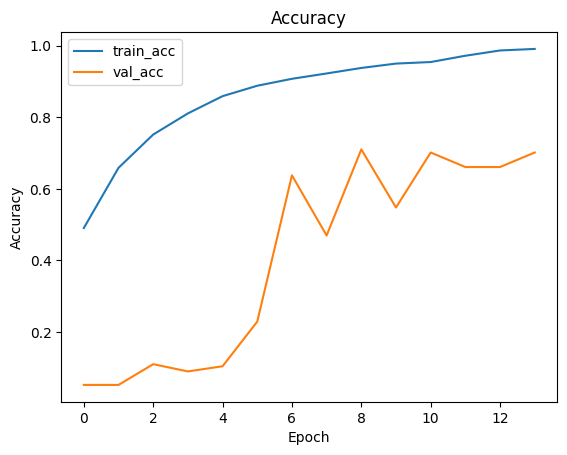

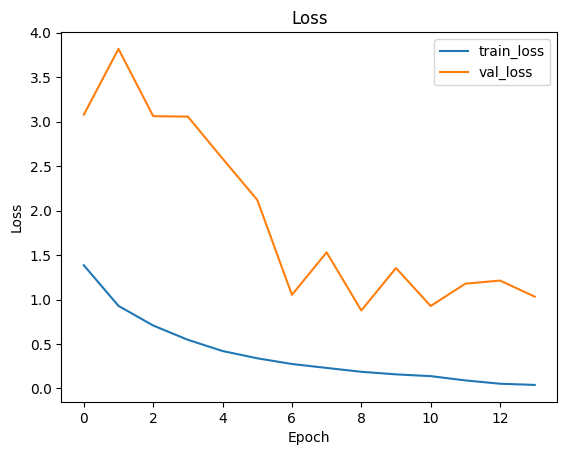

In [ ]:
##---------Type the code below this line------------------##

import pandas as pd
hist_path = OUT_DIR/'train_history.csv'
if hist_path.exists():
    hist = pd.read_csv(hist_path)
    # Accuracy plot
    plt.figure()
    plt.plot(hist['accuracy'], label='train_acc')
    plt.plot(hist['val_accuracy'], label='val_acc')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Accuracy')
    plt.show()

    # Loss plot
    plt.figure()
    plt.plot(hist['loss'], label='train_loss')
    plt.plot(hist['val_loss'], label='val_loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss')
    plt.show()
else:
    print("History file not found; train the model first.")

### Testing Accuracy & Loss

#### Testing Accuracy & Loss
* Test Accuracy: ~69.5%
* Test Loss: ~1.0
* Macro Precision: 0.462 
* Recall: 0.604
* F1: 0.512

#### Weighted Average
* Weighted Precision: 0.762
* Recall: 0.695
* F1:  0.720

* Macro AUC: ~0.90
* Macro Specificity: ~0.94

## 8) Grad-CAM (Explainability)
Generates Grad-CAM heatmaps for sample test images.


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=['Tensor(shape=(1, 64, 64, 3))']
  warnings.warn(msg)


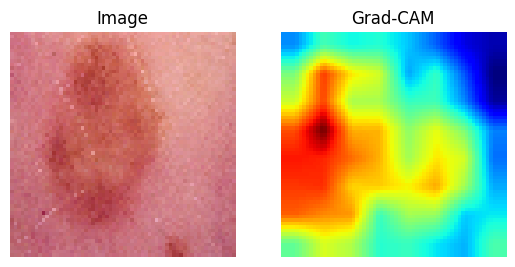

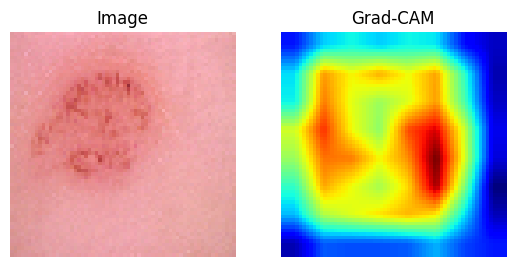

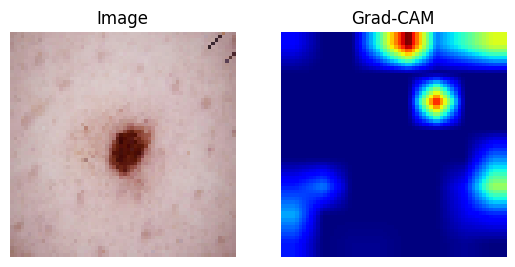

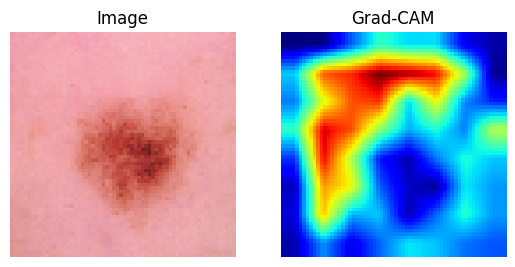

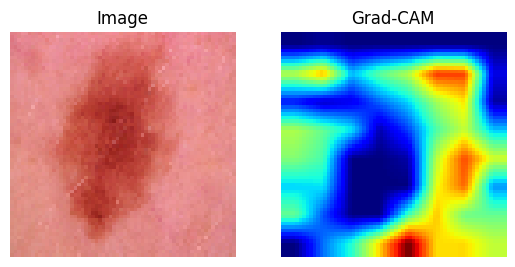

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name=None):
    # If no explicit last conv layer name is provided, find last Conv2D layer automatically
    if last_conv_layer_name is None:
        for layer in reversed(model.layers):
            if isinstance(layer, layers.Conv2D):
                last_conv_layer_name = layer.name
                break
    last_conv_layer = model.get_layer(last_conv_layer_name)
    grad_model = tf.keras.models.Model([model.inputs], [last_conv_layer.output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    heatmap = tf.math.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()
    return heatmap

# Demo on first few TEST images if available
sample_n = 5
sample_paths = df_test['image_path'].values[:sample_n] if len(df_test)>0 else []
for p in sample_paths:
    raw = tf.io.read_file(p)
    img = tf.image.decode_jpeg(raw, channels=3)
    img_resized = tf.image.resize(img, IMG_SIZE)
    arr = (tf.cast(img_resized, tf.float32) / 255.0)[tf.newaxis, ...]
    heatmap = make_gradcam_heatmap(arr, model)

    # Overlay
    heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], IMG_SIZE).numpy().squeeze()
    plt.figure()
    plt.subplot(1,2,1); plt.imshow(img_resized.numpy().astype('uint8')); plt.axis('off'); plt.title('Image')
    plt.subplot(1,2,2); plt.imshow(heatmap_resized, cmap='jet', alpha=1.0); plt.axis('off'); plt.title('Grad-CAM')
    plt.show()


## 9) Experiment Notes & Repro
- **Epochs:** 25, **Batch:** 128, **LR:** 1e-3 (Adamax)
- **Input:** 64×64, normalized to [0,1]
- **Oversampling:** Random oversampling on training only



#### Conclusion

Model achieves ~70% test accuracy.

Overfitting observed: training accuracy → ~100%, validation stuck around 65–70%.

Performs well on common classes (nv) but poorly on rare classes (df, mel, akiec) due to imbalance.

Improvements: data augmentation, class-weighted loss/focal loss, or transfer learning (EfficientNet/ResNet).